## fMRI Exploratory Analysis
can we

- Visualize anatomical or functional patterns

- Segment regions of interest (ROI) (e.g., using atlases or unsupervised clustering)

- Detect anomalies or patterns across subjects

Lets start with resting fMRI. I've found that there seems to be little difference between resting low risk and high risk.

C:\Users\benol\AppData\Local\Temp\ipykernel_23488\3946097567.py:8: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  mean_img = image.mean_img(subject_1)


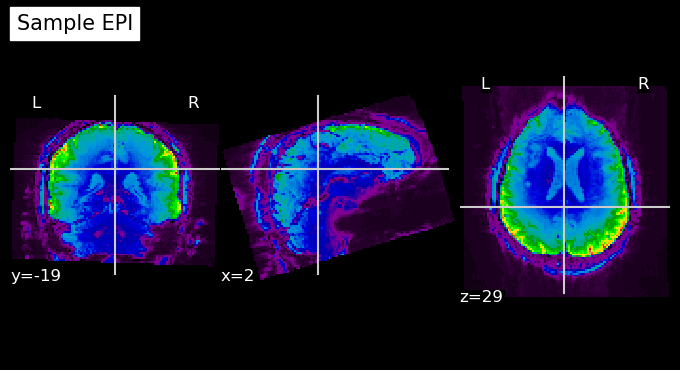

In [3]:
from nilearn import image
import nilearn.plotting as plotting
import os


data_dir = os.path.join('E:\\', 'neuro_data', 'ds004796')
subject_1 = os.path.join(data_dir, 'sub-01', 'func','sub-01_task-rest_dir-PA_bold.nii.gz')
mean_img = image.mean_img(subject_1)
plotting.plot_epi(mean_img, title="Sample EPI")

```.nii``` files are 4-dimension ```shape: (x, y, time)``` which means we can plot the slices over time.

In [ ]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display


img = nib.load(subject_1)
data = img.get_fdata()

# Choose which slice to view (e.g., 2 for middle axial)
z_slice = data.shape[2] // 2
slice_data = data[:, :, z_slice, :]  # shape: (x, y, time)
slice_data = (slice_data - np.min(slice_data)) / (np.max(slice_data) - np.min(slice_data))


# Set up interactive widget
@widgets.interact(t=widgets.IntSlider(min=0, max=slice_data.shape[-1]-1, step=1, value=0))
def update(t=0):
    plt.figure(figsize=(5, 5))
    plt.imshow(slice_data[:, :, t], cmap='gray', origin='lower')
    plt.title(f"Timepoint: {t}")
    plt.axis('off')
    plt.show()

interactive(children=(IntSlider(value=0, description='t', max=559), Output()), _dom_classes=('widget-interact'…

There can be some noise and shift during the scan, and the array will need to be flattened for classification. Standard methods include std or avg of the stack.

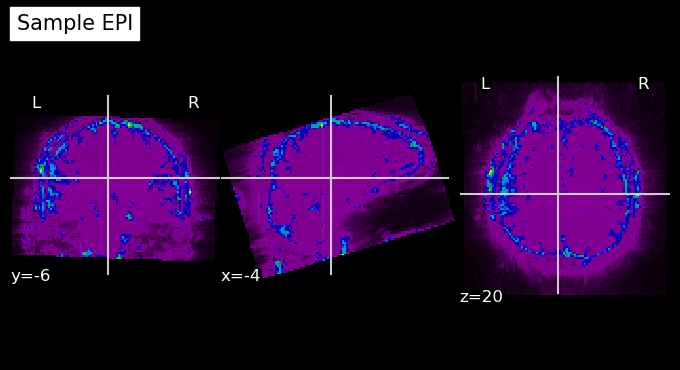

In [12]:
from nilearn import image
std_img = image.math_img("np.std(img, axis=-1)", img=subject_1)
plotting.plot_epi(std_img, title="Sample EPI")

Using the time series nature of the scans, we can graph correlation between regions to create a connectivity map. We'll use an atlas to segment and label regions of the brain. 

[get_dataset_dir] Dataset found in C:\Users\benol\nilearn_data\fsl


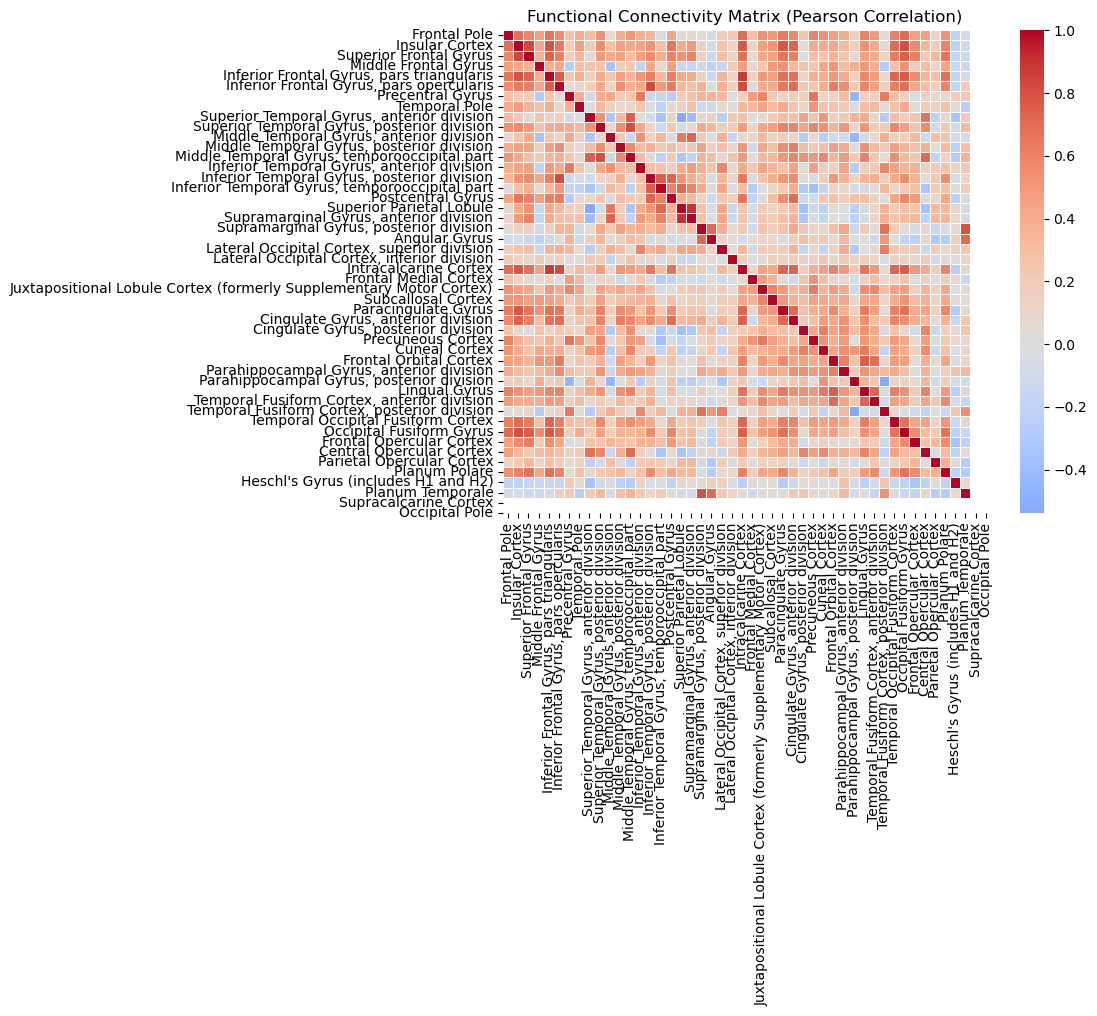

In [13]:
from nilearn.input_data import NiftiLabelsMasker
from nilearn import datasets, connectome
import seaborn as sns


atlas = datasets.fetch_atlas_harvard_oxford('cort-maxprob-thr50-1mm')
masker = NiftiLabelsMasker(labels_img=atlas.maps, standardize=True)
timeseries = masker.fit_transform(subject_1)

correlation_measure = connectome.ConnectivityMeasure(kind='correlation')
correlation_matrix = connectome.ConnectivityMeasure(kind='correlation').fit_transform([timeseries])[0]

corr = np.array(correlation_matrix)

# Remove 'Background' label if present (index 0 in atlas.labels)
region_labels = atlas.labels[1:]
corr = corr[1:, 1:]

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr, xticklabels=region_labels, yticklabels=region_labels,
            cmap='coolwarm', center=0, square=True, linewidths=0.5)

plt.title("Functional Connectivity Matrix (Pearson Correlation)")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

using known atlases, we can used atlas based segmentation to extract ROIs

C:\Users\benol\AppData\Local\Temp\ipykernel_23488\3202696850.py:5: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  resampled_atlas = resample_to_img(atlas.maps, mean_img)
c:\Users\benol\miniconda3\envs\mne\Lib\site-packages\nilearn\image\resampling.py:805: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  return resample_img(


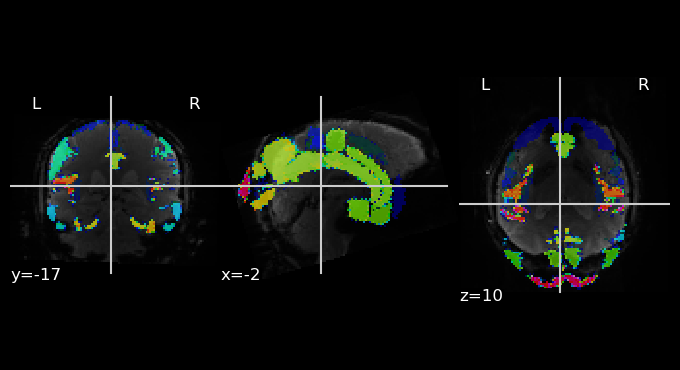

In [14]:
from nilearn.image import resample_to_img
from nilearn.plotting import plot_roi

#Atlas-Based Segmentation
resampled_atlas = resample_to_img(atlas.maps, mean_img)
plot_roi(resampled_atlas, bg_img=mean_img)

using unsupervised clustering, via ```kmeans``` we can cluster voxels for areas of interest.

[Parcellations.fit] Loading data from [E:\neuro_data\ds004796\sub-01\func\sub-01_task-rest_dir-PA_bold.nii.gz]
[Parcellations.fit] Computing the mask
[Parcellations.fit] Resampling mask
[Parcellations.fit] Finished fit
[Parcellations.fit] Loading data
[Parcellations.fit] Loading data from Nifti1Image('E:\neuro_data\ds004796\sub-01\func\sub-01_task-rest_dir-PA_bold.nii.gz')
[Parcellations.fit] Smoothing images
[Parcellations.fit] Extracting region signals
[Parcellations.fit] Cleaning extracted signals
[Parcellations.fit] computing kmeans


C:\Users\benol\AppData\Local\Temp\ipykernel_23488\2938797676.py:5: FutureWarning: The nifti_maps_masker_ attribute is deprecated andwill be removed in Nilearn 0.11.3. Please use maps_masker_ instead.
  parcellator.fit(subject_1)


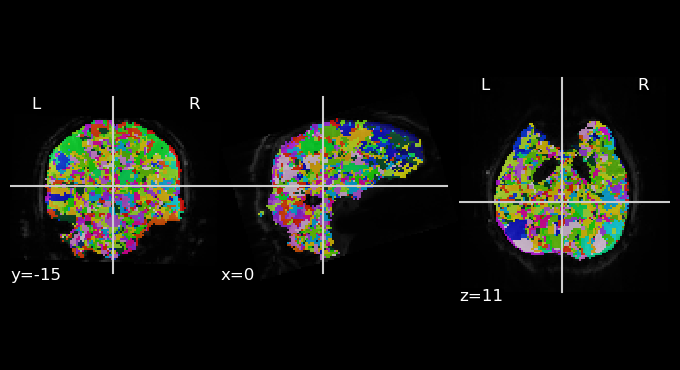

In [15]:
from nilearn.regions import Parcellations

# Unsupervised Segmentation (e.g., Clustering Voxels)
parcellator = Parcellations(n_parcels=50, method='kmeans', standardize=True)
parcellator.fit(subject_1)
plot_roi(parcellator.labels_img_, bg_img=mean_img)

I'm interested to see if there is any difference between high and low risk individuals in terms of their correlation matrices. If you choose to do this, be aware that it will take roughly an hour to extract all the features. considering using a subset of the population.

In [ ]:
import json
#Visualize Feature Differences Between low risk and highrisk populations

# Extract Per-Subject Feature Vectors
atlas = datasets.fetch_atlas_harvard_oxford('cort-maxprob-thr50-1mm')
labels_img = atlas.maps
masker = NiftiLabelsMasker(labels_img=labels_img, standardize=True)

def extract_features(fmri_path):
    timeseries = masker.fit_transform(fmri_path)  # (timepoints, n_regions)
    # Option 1: Flatten full correlation matrix
    corr = connectome.ConnectivityMeasure(kind='correlation').fit_transform([timeseries])[0]
    upper_tri = corr[np.triu_indices_from(corr, k=1)]  # Flatten upper triangle
    return upper_tri

def get_sub_files(sub_filepath, labels_filepath, data_dir):
    with open(sub_filepath, 'r') as f:
        fmri_subjects = json.load(f)

    with open(labels_filepath, 'r') as f:
        risk_labels = json.load(f)

    low_risk_subs = [sub for sub in fmri_subjects if risk_labels[sub] == 0]
    high_risk_subs = [sub for sub in fmri_subjects if risk_labels[sub] == 1]

    low_files = [os.path.join(data_dir, sub, 'func',f'{sub}_task-rest_dir-PA_bold.nii.gz') for sub in low_risk_subs]
    high_files = [os.path.join(data_dir, sub, 'func',f'{sub}_task-rest_dir-PA_bold.nii.gz') for sub in high_risk_subs]

    return low_files, high_files

fmri_subjects = r"..\data\available_fmri_subjects.json"
risk_labels = r"..\data\sub_risk_labels.json"

low_files, high_files = get_sub_files(fmri_subjects, risk_labels, data_dir)

X = [extract_features(p) for p in low_files + high_files]
y = [0] * len(low_files) + [1] * len(high_files)  # 0 = Group 1, 1 = Group 2



[get_dataset_dir] Dataset found in C:\Users\benol\nilearn_data\fsl


c:\Users\benol\miniconda3\envs\mne\Lib\site-packages\nilearn\maskers\nifti_labels_masker.py:888: UserWarning: After resampling the label image to the data image, the following labels were removed: {np.uint8(37), np.uint8(14)}. Label image only contains 46 labels (including background).
  warnings.warn(
c:\Users\benol\miniconda3\envs\mne\Lib\site-packages\nilearn\maskers\nifti_labels_masker.py:888: UserWarning: After resampling the label image to the data image, the following labels were removed: {np.uint8(25)}. Label image only contains 45 labels (including background).
  warnings.warn(
c:\Users\benol\miniconda3\envs\mne\Lib\site-packages\nilearn\maskers\nifti_labels_masker.py:888: UserWarning: After resampling the label image to the data image, the following labels were removed: {np.uint8(37)}. Label image only contains 47 labels (including background).
  warnings.warn(
c:\Users\benol\miniconda3\envs\mne\Lib\site-packages\nilearn\maskers\nifti_labels_masker.py:888: UserWarning: After 

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (68,) + inhomogeneous part.

due to missing data (missing time series for some ROIs or lack of coverage) not every extracted upper triangle has the same length (number of valid regions) so filter out the shorter arrays.

In [21]:
expected_length = 1081

X_filtered = []
y_filtered = []

for i, j in zip(X,y): 
    if len(i) == expected_length:
        X_filtered.append(i)
        y_filtered.append(j)

X = np.vstack(X_filtered)
y = np.array(y_filtered)

Lets project these down to 2-dim using UMAP to preserve structure and plot the results. Honestly not promising and I will need to investigate the other states.

c:\Users\benol\miniconda3\envs\mne\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\benol\miniconda3\envs\mne\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


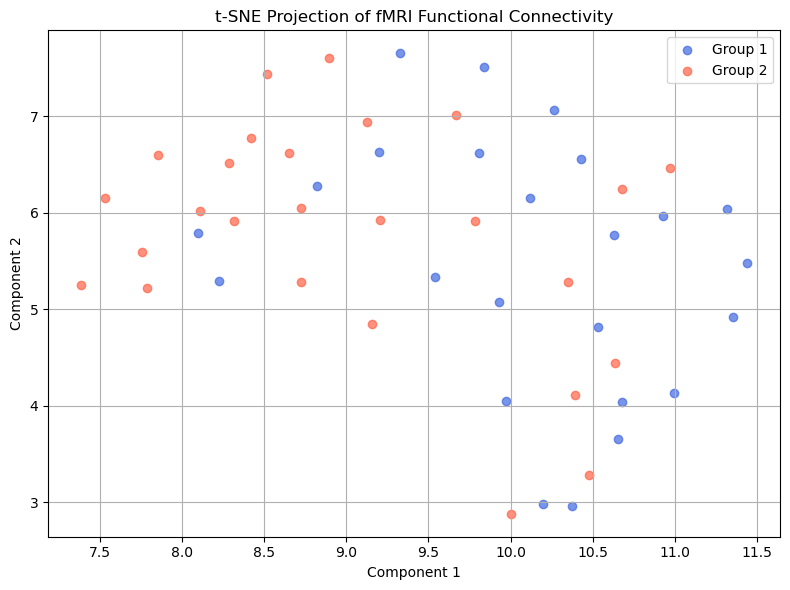

In [26]:
import umap.umap_ as umap
import matplotlib.pyplot as plt

X_umap = umap.UMAP(n_neighbors=10, min_dist=0.1, metric='correlation', random_state=42).fit_transform(X)

# Plot
plt.figure(figsize=(8, 6))
colors = ['royalblue', 'tomato']
labels = ['Group 1', 'Group 2']

for label, color in zip([0, 1], colors):
    idx = y == label
    plt.scatter(X_umap[idx, 0], X_umap[idx, 1], label=labels[label], alpha=0.7, color=color)

plt.title("t-SNE Projection of fMRI Functional Connectivity")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [28]:
conn_group1 = [connectome.ConnectivityMeasure().fit_transform([masker.fit_transform(p)])[0] for p in low_files]
conn_group2 = [connectome.ConnectivityMeasure().fit_transform([masker.fit_transform(p)])[0] for p in high_files]

for i, x in enumerate(conn_group1):
    print(f"Subject {i}: feature shape = {np.array(x).shape}")
for i, x in enumerate(conn_group2):
    print(f"Subject {i}: feature shape = {np.array(x).shape}")



c:\Users\benol\miniconda3\envs\mne\Lib\site-packages\nilearn\maskers\nifti_labels_masker.py:888: UserWarning: After resampling the label image to the data image, the following labels were removed: {np.uint8(37), np.uint8(14)}. Label image only contains 46 labels (including background).
  warnings.warn(
c:\Users\benol\miniconda3\envs\mne\Lib\site-packages\nilearn\maskers\nifti_labels_masker.py:888: UserWarning: After resampling the label image to the data image, the following labels were removed: {np.uint8(25)}. Label image only contains 45 labels (including background).
  warnings.warn(
c:\Users\benol\miniconda3\envs\mne\Lib\site-packages\nilearn\maskers\nifti_labels_masker.py:888: UserWarning: After resampling the label image to the data image, the following labels were removed: {np.uint8(37)}. Label image only contains 47 labels (including background).
  warnings.warn(
c:\Users\benol\miniconda3\envs\mne\Lib\site-packages\nilearn\maskers\nifti_labels_masker.py:888: UserWarning: After 

Subject 0: feature shape = (47, 47)
Subject 1: feature shape = (47, 47)
Subject 2: feature shape = (47, 47)
Subject 3: feature shape = (45, 45)
Subject 4: feature shape = (45, 45)
Subject 5: feature shape = (44, 44)
Subject 6: feature shape = (47, 47)
Subject 7: feature shape = (47, 47)
Subject 8: feature shape = (47, 47)
Subject 9: feature shape = (47, 47)
Subject 10: feature shape = (46, 46)
Subject 11: feature shape = (47, 47)
Subject 12: feature shape = (47, 47)
Subject 13: feature shape = (47, 47)
Subject 14: feature shape = (45, 45)
Subject 15: feature shape = (47, 47)
Subject 16: feature shape = (47, 47)
Subject 17: feature shape = (47, 47)
Subject 18: feature shape = (47, 47)
Subject 19: feature shape = (47, 47)
Subject 20: feature shape = (47, 47)
Subject 21: feature shape = (47, 47)
Subject 22: feature shape = (47, 47)
Subject 23: feature shape = (47, 47)
Subject 24: feature shape = (47, 47)
Subject 25: feature shape = (47, 47)
Subject 26: feature shape = (47, 47)
Subject 27:

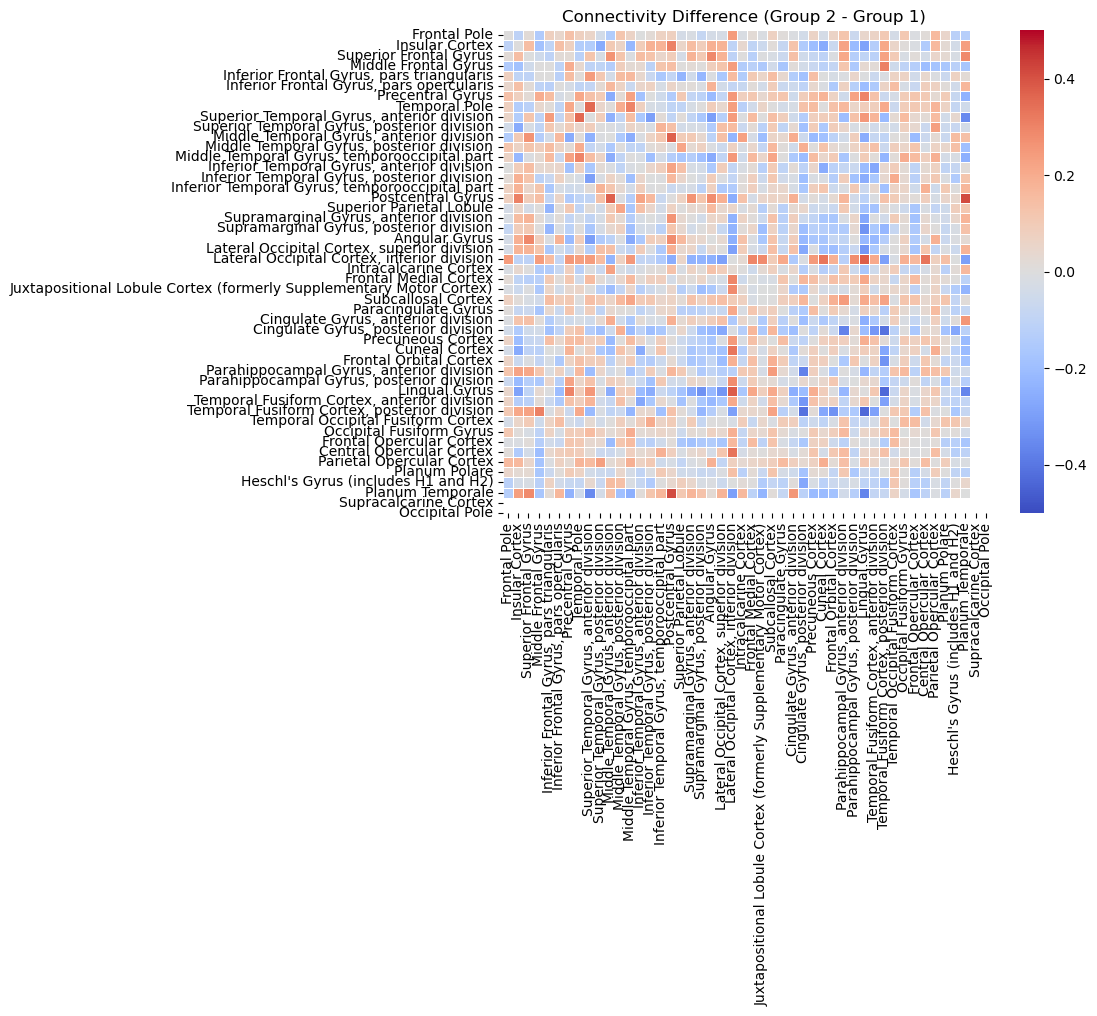

In [39]:
conn_group1_filtered = []
conn_group2_filtered = []

for i, j in zip(conn_group1,conn_group2): 
    if len(i) == 47 and len(j) == 47:
        conn_group1_filtered.append(i)
        conn_group2_filtered.append(j)


avg_conn_group1 = np.mean(conn_group1_filtered, axis=0)
avg_conn_group2 = np.mean(conn_group2_filtered, axis=0)
diff_matrix = avg_conn_group2 - avg_conn_group1

def plot_connectivity_matrix(matrix, title, labels, vmin=-1, vmax=1, center=0):
    plt.figure(figsize=(12, 10))
    sns.heatmap(matrix, xticklabels=labels, yticklabels=labels,
                cmap="coolwarm", vmin=vmin, vmax=vmax, center=center,
                square=True, linewidths=0.5)
    plt.title(title)
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

# plot_connectivity_matrix(avg_conn_group1[1:, 1:], "Average Connectivity: Group 1", region_labels)
# plot_connectivity_matrix(avg_conn_group2[1:, 1:], "Average Connectivity: Group 2", region_labels)
plot_connectivity_matrix(diff_matrix[1:, 1:], "Connectivity Difference (Group 2 - Group 1)", region_labels, vmin=-0.5, vmax=0.5)

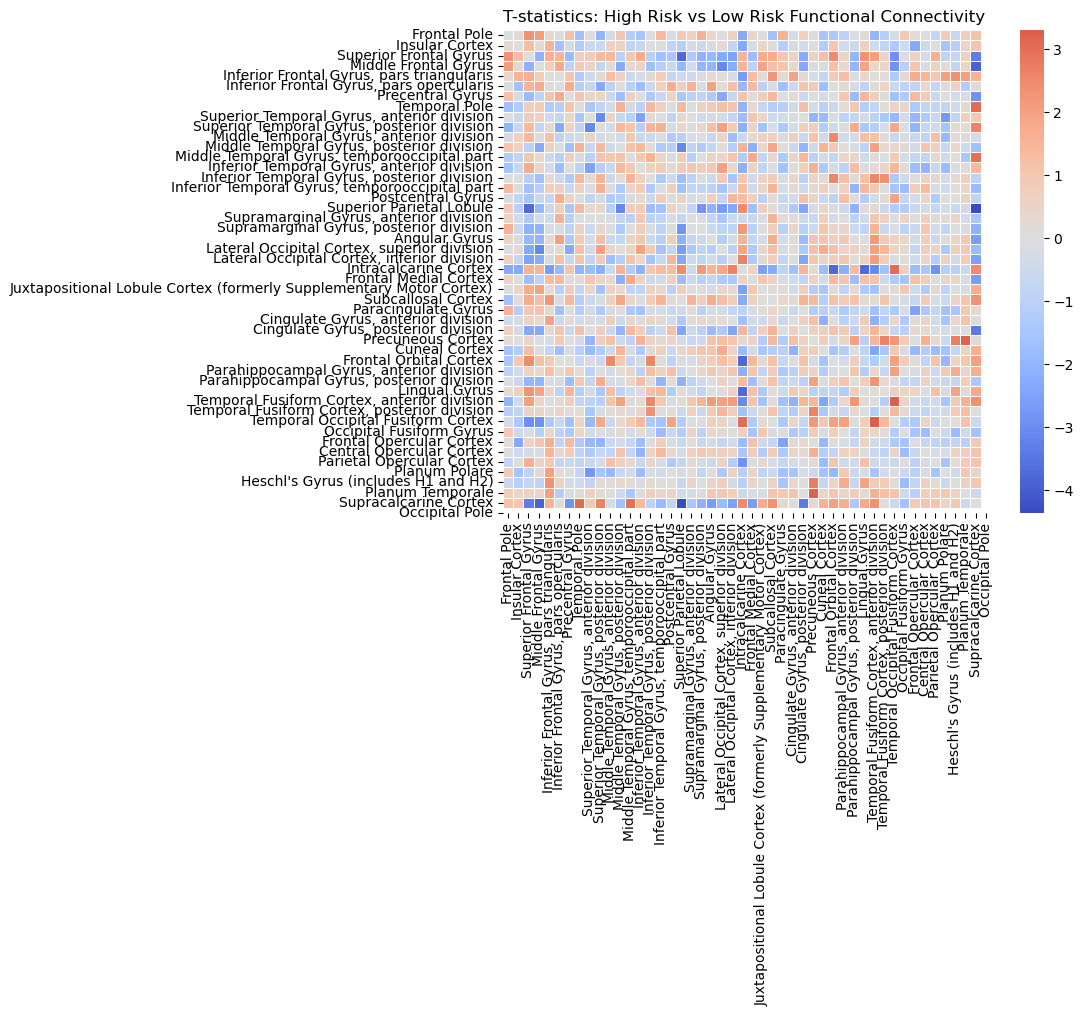

In [46]:
from scipy.stats import ttest_ind

# Convert to array
group1 = X[y == 0]
group2 = X[y == 1]

t_stats, p_vals = ttest_ind(group1, group2)

n_regions = 47  # Adjust if your atlas has more or fewer
t_matrix = np.zeros((n_regions, n_regions))
p_matrix = np.zeros((n_regions, n_regions))

# Fill upper triangle
triu_indices = np.triu_indices(n_regions, k=1)
t_matrix[triu_indices] = t_stats
p_matrix[triu_indices] = p_vals

# Mirror to lower triangle to make it symmetric
t_matrix += t_matrix.T
p_matrix += p_matrix.T

plt.figure(figsize=(12, 10))
sns.heatmap(t_matrix, xticklabels=region_labels, yticklabels=region_labels,
            cmap='coolwarm', center=0, square=True, linewidths=0.5)
plt.title("T-statistics: High Risk vs Low Risk Functional Connectivity")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()